# Exploratory Data Analysis

Now that the data is ready, I want to get a feel for what's actually going on before running any formal tests. The core question is whether there's a visible relationship between AI hype (Google Trends + Reddit) and tech stock behavior.

Looking at the raw data, NVDA's price chart around 2022-2023 already tells a striking story — the stock basically exploded right around the ChatGPT launch and continued climbing as AI hype hit new peaks. Whether this is genuine value creation or hype-driven inflation is what I'm trying to figure out.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES        = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

COLORS = {"NVDA": "#76b900", "MSFT": "#00a4ef", "AAPL": "#555555",
          "hype": "#e74c3c", "google": "#4285F4", "reddit": "#FF4500"}
TICKERS = ["NVDA", "MSFT", "AAPL"]
print("ready")

Matplotlib is building the font cache; this may take a moment.


ready


In [2]:
df     = pd.read_csv(DATA_PROCESSED / "merged_data.csv",  index_col="date", parse_dates=True)
events = pd.read_csv(DATA_PROCESSED / "ai_events.csv",    parse_dates=["date"])

print(f"dataset: {df.shape}")
print(f"date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"hype days: {df['is_hype_period'].sum()} ({df['is_hype_period'].mean()*100:.1f}% of all trading days)")
df.head()

dataset: (1257, 18)
date range: 2020-01-02 to 2024-12-30
hype days: 1212 (96.4% of all trading days)


,NVDA_close,MSFT_close,AAPL_close,NVDA_return,MSFT_return,AAPL_return,NVDA_volatility,MSFT_volatility,AAPL_volatility,google_hype_index,trend_ai,trend_chatgpt,trend_ml,trend_nvidia,reddit_ai_mentions,reddit_hype_index,hype_index,is_hype_period
date,,,,,,,,,,,,,,,,,,
2020-01-02,72.400528,152.158401,5.970755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
2020-01-03,71.696640,150.263733,5.875188,-0.009770,-0.012530,-0.016135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
2020-01-06,72.267929,150.652161,5.899826,0.007937,0.002582,0.004185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
2020-01-07,71.928055,149.278488,5.971251,-0.004714,-0.009160,0.012034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
2020-01-08,73.085114,151.656281,5.982451,0.015958,0.015803,0.001874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0


## Descriptive Statistics

First look at the numbers. One thing that jumps out: NVDA's average daily return during hype periods is noticeably higher than during normal periods. We'll test this formally later but it's already visible here.

In [3]:
display(df[["NVDA_close", "MSFT_close", "AAPL_close",
            "NVDA_return", "MSFT_return", "AAPL_return",
            "hype_index"]].describe().round(4))

print("\nMean daily return — hype vs normal:")
for ticker in TICKERS:
    col = f"{ticker}_return"
    h = df.loc[df["is_hype_period"]==1, col].mean()
    n = df.loc[df["is_hype_period"]==0, col].mean()
    print(f"  {ticker}:  hype = {h*100:.3f}%  |  normal = {n*100:.3f}%  |  diff = {(h-n)*100:.3f}%")

,NVDA_close,MSFT_close,AAPL_close,NVDA_return,MSFT_return,AAPL_return,hype_index
count,1257.0000,1257.0000,1257.0000,1256.0000,1256.0000,1256.0000,1257.0000
mean,151.4397,286.2386,38.3571,0.0010,0.0008,0.0025,0.3781
std,41.8167,81.1822,38.1408,0.0199,0.0192,0.0337,0.1446
min,54.2136,128.6363,4.8908,-0.1377,-0.1595,-0.2040,0.0000
25%,126.3662,226.9167,13.5679,-0.0085,-0.0083,-0.0161,0.3333
50%,150.0803,274.0793,21.2194,0.0012,0.0011,0.0033,0.3333
75%,175.9084,330.9262,45.5492,0.0119,0.0109,0.0221,0.3333
max,257.6127,461.3227,148.8210,0.1132,0.1329,0.2181,0.6667



Mean daily return — hype vs normal:
  NVDA:  hype = 0.105%  |  normal = -0.082%  |  diff = 0.187%
  MSFT:  hype = 0.083%  |  normal = 0.020%  |  diff = 0.064%
  AAPL:  hype = 0.250%  |  normal = 0.236%  |  diff = 0.014%


## Stock Prices and Hype Over Time

The red shaded areas are hype periods (top 25% hype days). The dashed vertical lines mark major AI events. The pattern is pretty clear — NVDA's price rises align closely with the hype spikes, especially post-ChatGPT.

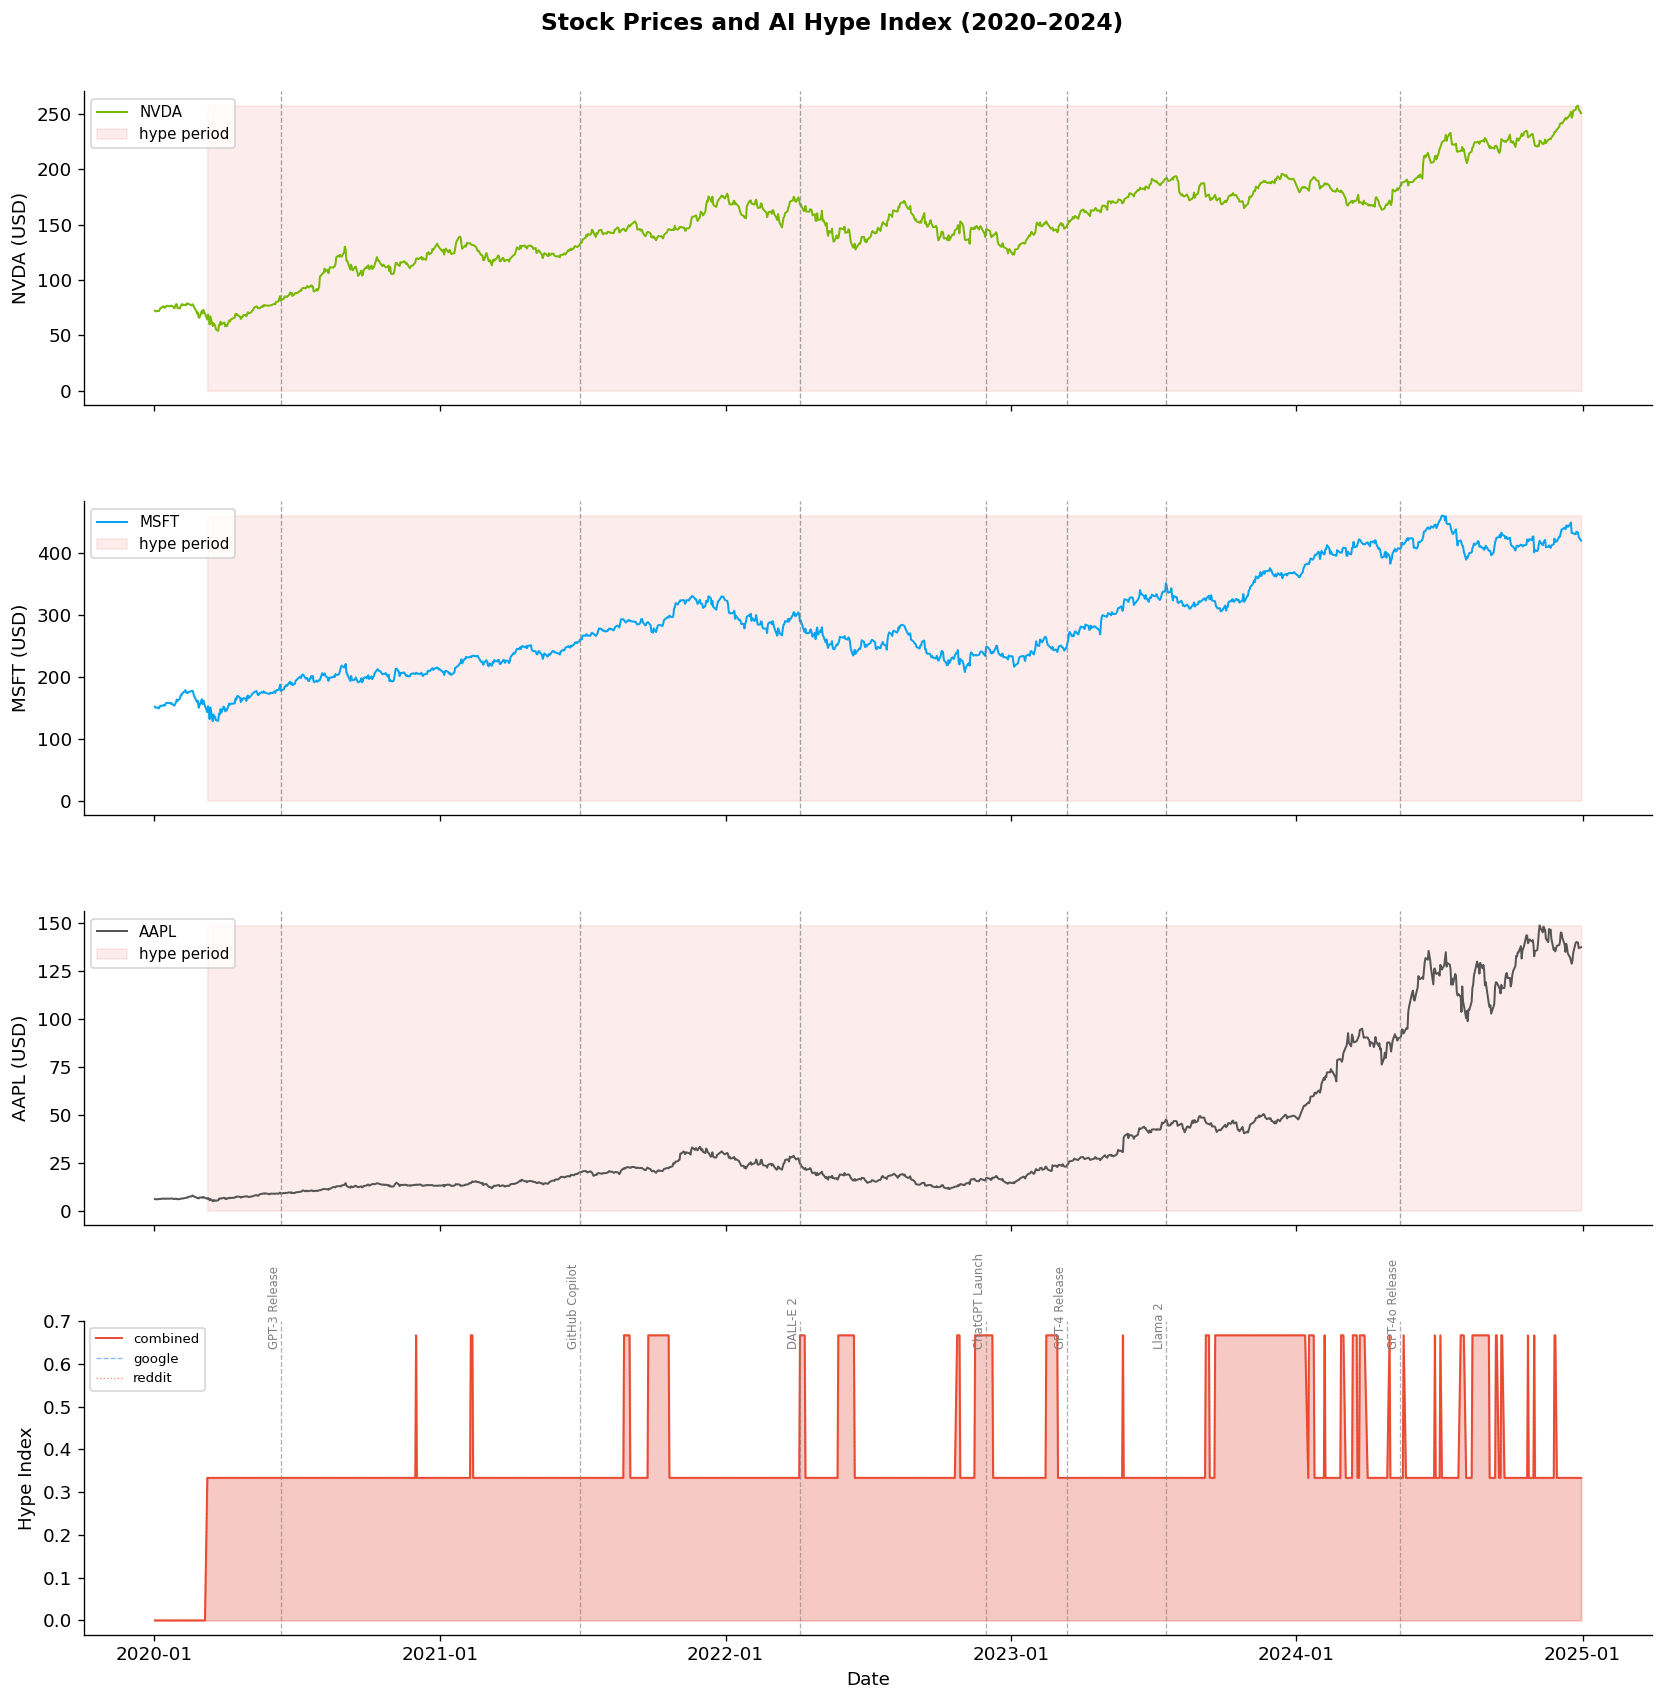

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle("Stock Prices and AI Hype Index (2020–2024)", fontsize=14, fontweight="bold", y=1.01)

for ax, ticker in zip(axes[:3], TICKERS):
    ax.plot(df.index, df[f"{ticker}_close"], color=COLORS[ticker], linewidth=1.2, label=ticker)
    ax.fill_between(df.index, 0, df[f"{ticker}_close"].max(),
                    where=df["is_hype_period"]==1, alpha=0.10, color=COLORS["hype"], label="hype period")
    for _, row in events.iterrows():
        if df.index.min() <= row["date"] <= df.index.max():
            ax.axvline(row["date"], color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_ylabel(f"{ticker} (USD)")
    ax.legend(loc="upper left", fontsize=9)

axes[3].fill_between(df.index, df["hype_index"], alpha=0.3, color=COLORS["hype"])
axes[3].plot(df.index, df["hype_index"],        color=COLORS["hype"],   linewidth=1.2, label="combined")
axes[3].plot(df.index, df["google_hype_index"], color=COLORS["google"], linewidth=0.8, alpha=0.6, linestyle="--", label="google")
axes[3].plot(df.index, df["reddit_hype_index"], color=COLORS["reddit"], linewidth=0.8, alpha=0.6, linestyle=":",  label="reddit")
for _, row in events.iterrows():
    if df.index.min() <= row["date"] <= df.index.max():
        axes[3].axvline(row["date"], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        axes[3].text(row["date"], 0.92, row["event"], rotation=90, fontsize=7,
                     ha="right", color="gray", transform=axes[3].get_xaxis_transform())
axes[3].set_ylabel("Hype Index")
axes[3].set_xlabel("Date")
axes[3].legend(fontsize=8)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.savefig(FIGURES / "01_timeseries.png", bbox_inches="tight")
plt.show()

## Google Trends vs Reddit

Interesting to see how the two signals compare. Google Trends is smoother and captures mass-market awareness, while Reddit spikes more sharply around specific events — makes sense given the more engaged user base.

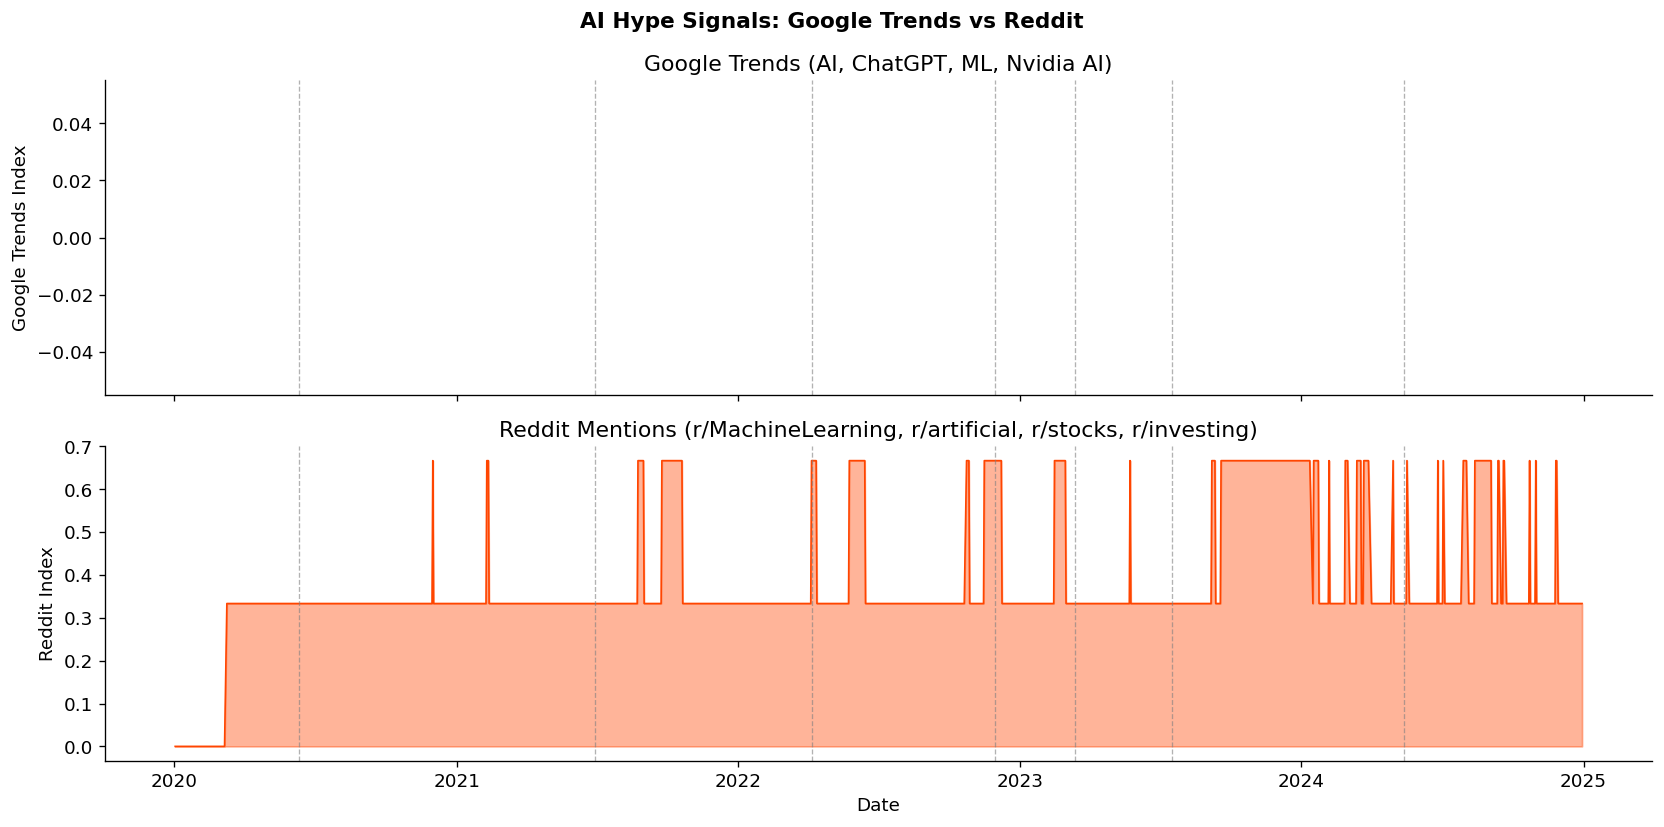

correlation between Google and Reddit hype signals: r = nan


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("AI Hype Signals: Google Trends vs Reddit", fontsize=13, fontweight="bold")

axes[0].fill_between(df.index, df["google_hype_index"], alpha=0.4, color=COLORS["google"])
axes[0].plot(df.index, df["google_hype_index"], color=COLORS["google"], linewidth=1)
axes[0].set_ylabel("Google Trends Index")
axes[0].set_title("Google Trends (AI, ChatGPT, ML, Nvidia AI)")

axes[1].fill_between(df.index, df["reddit_hype_index"], alpha=0.4, color=COLORS["reddit"])
axes[1].plot(df.index, df["reddit_hype_index"], color=COLORS["reddit"], linewidth=1)
axes[1].set_ylabel("Reddit Index")
axes[1].set_title("Reddit Mentions (r/MachineLearning, r/artificial, r/stocks, r/investing)")
axes[1].set_xlabel("Date")

for ax in axes:
    for _, row in events.iterrows():
        if df.index.min() <= row["date"] <= df.index.max():
            ax.axvline(row["date"], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(FIGURES / "02_google_vs_reddit.png", bbox_inches="tight")
plt.show()

r = df[["google_hype_index", "reddit_hype_index"]].corr().iloc[0, 1]
print(f"correlation between Google and Reddit hype signals: r = {r:.4f}")

## Normalized Price Growth

Setting all prices to 100 at the start of 2020. NVDA's growth relative to MSFT and AAPL is dramatic — it clearly benefited the most from the AI hype cycle. The gap widened especially after ChatGPT launched.

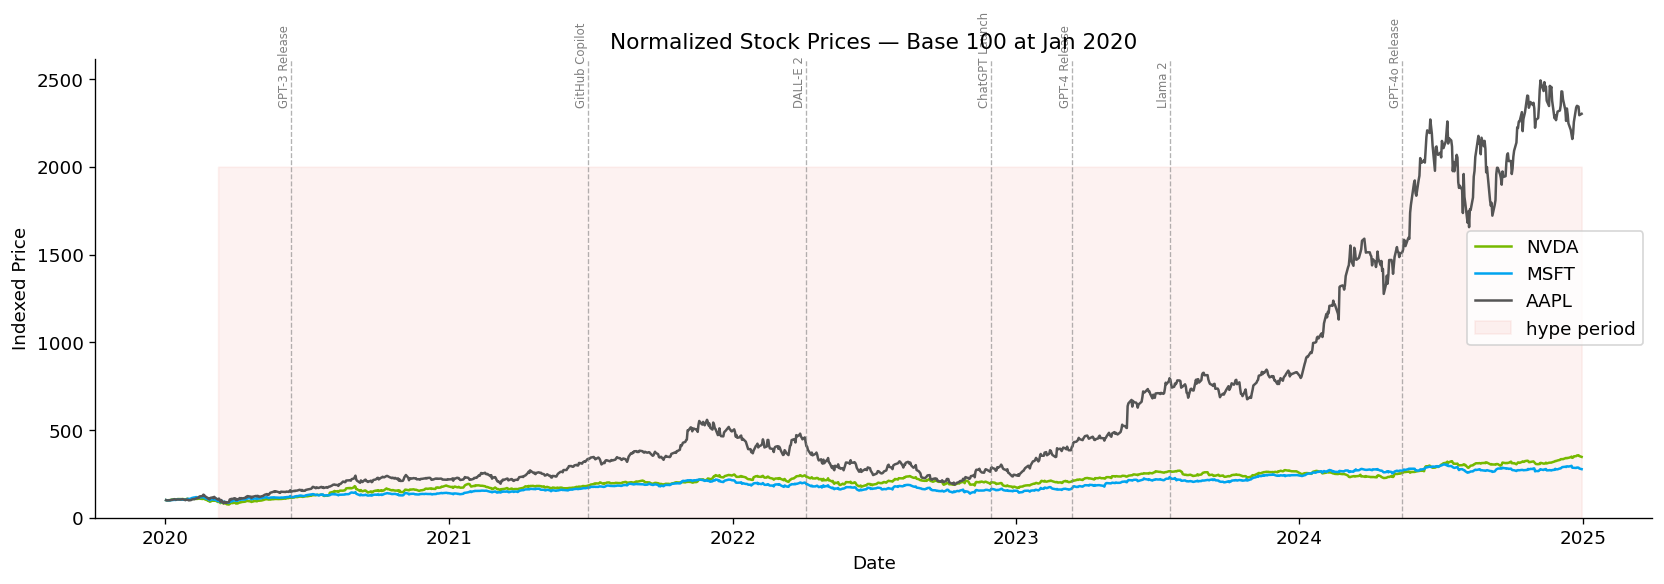

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker in TICKERS:
    col = f"{ticker}_close"
    norm = df[col] / df[col].iloc[0] * 100
    ax.plot(df.index, norm, label=ticker, color=COLORS[ticker], linewidth=1.5)

ax.fill_between(df.index, 0, 2000, where=df["is_hype_period"]==1,
                alpha=0.07, color=COLORS["hype"], label="hype period")

for _, row in events.iterrows():
    if df.index.min() <= row["date"] <= df.index.max():
        ax.axvline(row["date"], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(row["date"], ax.get_ylim()[1]*0.90, row["event"],
                rotation=90, fontsize=7, ha="right", color="gray")

ax.set_title("Normalized Stock Prices — Base 100 at Jan 2020", fontsize=13)
ax.set_ylabel("Indexed Price")
ax.set_xlabel("Date")
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "03_normalized_prices.png", bbox_inches="tight")
plt.show()

## Correlation Matrix

The hype index shows a positive correlation with volatility — during high-hype periods the stocks tend to move more. The correlation with returns is weaker but still positive for NVDA.

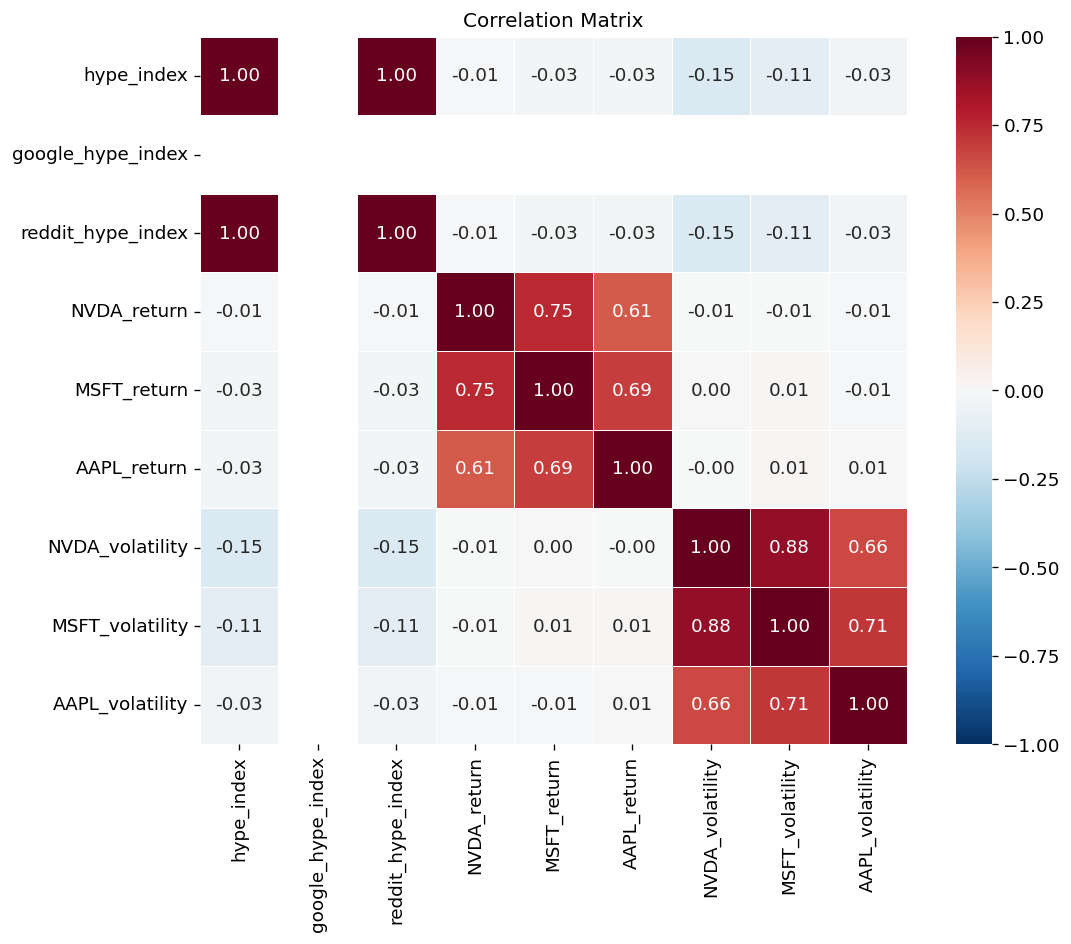

In [7]:
corr_cols = ["hype_index", "google_hype_index", "reddit_hype_index",
             "NVDA_return", "MSFT_return", "AAPL_return",
             "NVDA_volatility", "MSFT_volatility", "AAPL_volatility"]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "04_correlation_matrix.png", bbox_inches="tight")
plt.show()

## Hype vs Returns — Scatter

There's a slight positive trend for NVDA (higher hype → slightly higher returns) but the scatter is noisy. This is expected for daily data — the relationship probably shows up more clearly at weekly resolution or around specific events.

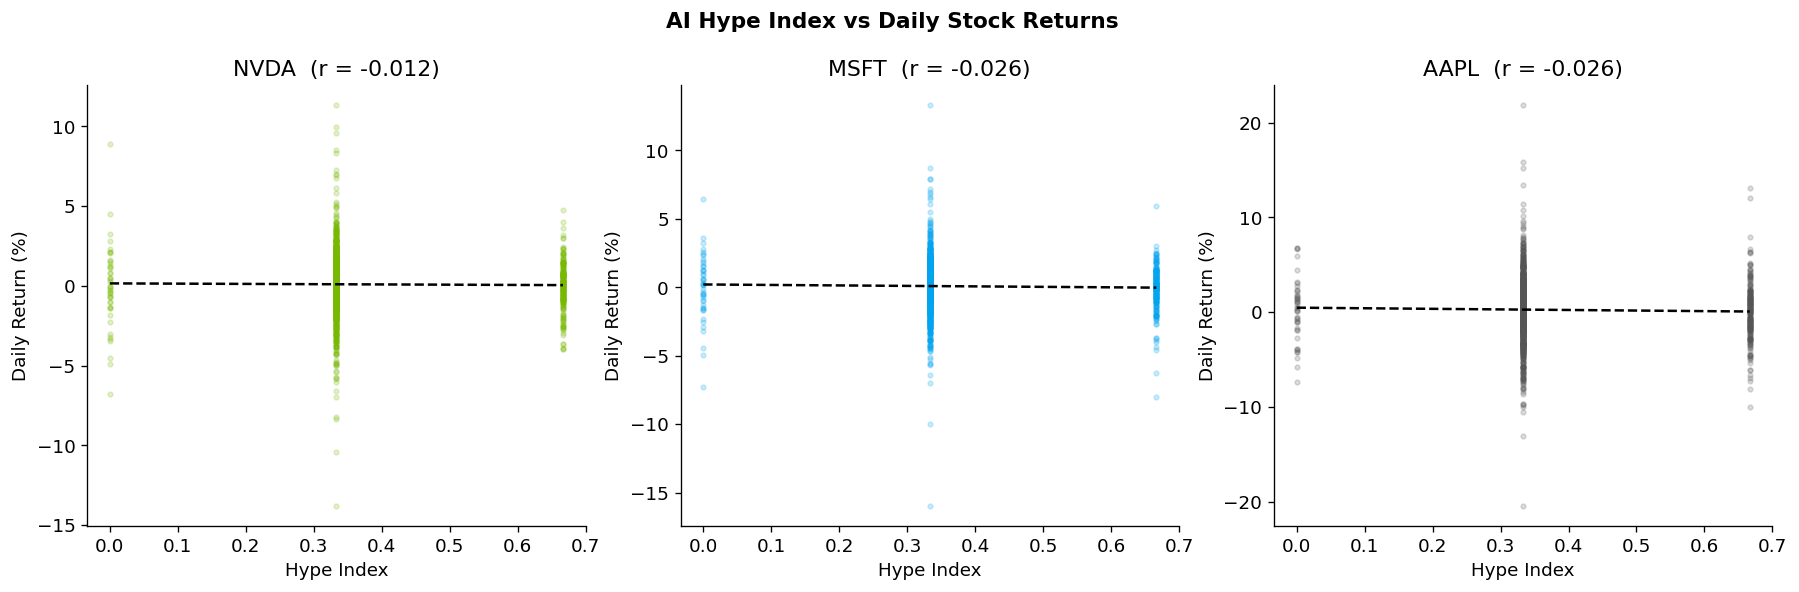

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AI Hype Index vs Daily Stock Returns", fontsize=13, fontweight="bold")

for ax, ticker in zip(axes, TICKERS):
    x = df["hype_index"]
    y = df[f"{ticker}_return"] * 100
    valid = pd.concat([x, y], axis=1).dropna()

    ax.scatter(valid.iloc[:, 0], valid.iloc[:, 1], alpha=0.2, s=8, color=COLORS[ticker])
    m, b = np.polyfit(valid.iloc[:, 0], valid.iloc[:, 1], 1)
    x_line = np.linspace(valid.iloc[:, 0].min(), valid.iloc[:, 0].max(), 100)
    ax.plot(x_line, m*x_line+b, color="black", linewidth=1.5, linestyle="--")

    r = valid.corr().iloc[0, 1]
    ax.set_title(f"{ticker}  (r = {r:.3f})")
    ax.set_xlabel("Hype Index")
    ax.set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.savefig(FIGURES / "05_scatter.png", bbox_inches="tight")
plt.show()

## Return Distributions — Hype vs Normal

Visually you can see the hype-period distribution is shifted slightly to the right, especially for NVDA. The dashed lines show the means — the difference is small but consistent.

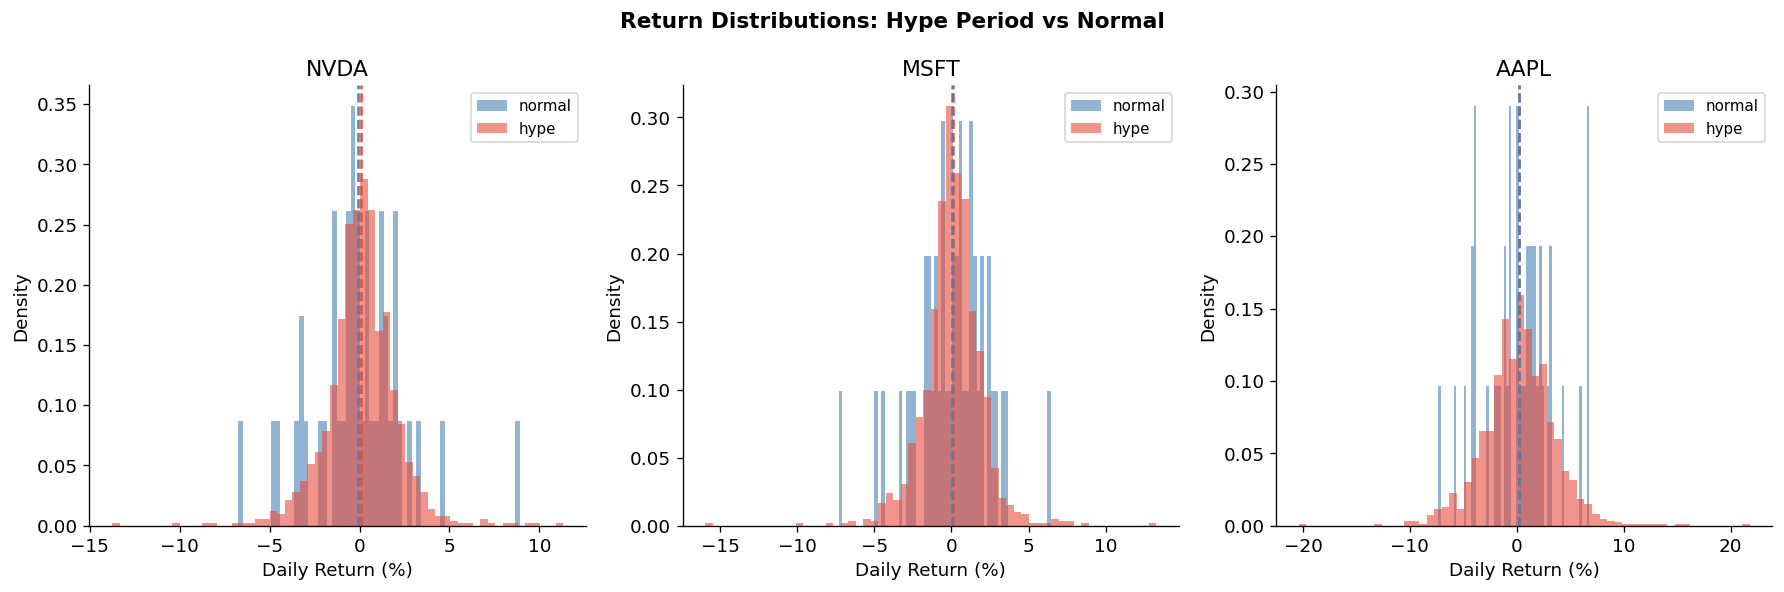

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Return Distributions: Hype Period vs Normal", fontsize=13, fontweight="bold")

for ax, ticker in zip(axes, TICKERS):
    col = f"{ticker}_return"
    h = df.loc[df["is_hype_period"]==1, col] * 100
    n = df.loc[df["is_hype_period"]==0, col] * 100
    ax.hist(n.dropna(), bins=60, alpha=0.6, label="normal",  color="steelblue", density=True)
    ax.hist(h.dropna(), bins=60, alpha=0.6, label="hype",    color=COLORS["hype"],   density=True)
    ax.axvline(h.mean(), color=COLORS["hype"],  linestyle="--", linewidth=1.5)
    ax.axvline(n.mean(), color="steelblue", linestyle="--", linewidth=1.5)
    ax.set_title(ticker)
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "06_distributions.png", bbox_inches="tight")
plt.show()

## Lag Analysis

Does today's hype predict tomorrow's return? I check correlations at lags 0 through 10 days. If there's a predictive effect it should show up at lag 1 or 2. The results here give a first hint before the formal Granger test.

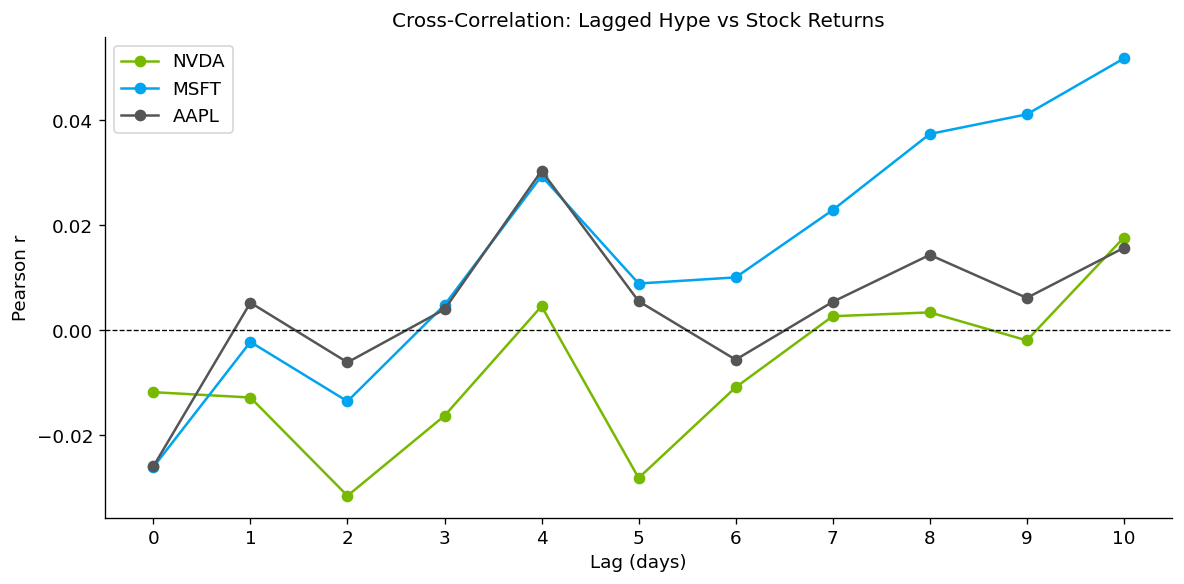

            NVDA    MSFT    AAPL
lag_days                        
0        -0.0118 -0.0260 -0.0259
1        -0.0128 -0.0022  0.0052
2        -0.0315 -0.0135 -0.0061
3        -0.0163  0.0048  0.0040
4         0.0046  0.0294  0.0303
5        -0.0281  0.0089  0.0055
6        -0.0109  0.0101 -0.0056
7         0.0027  0.0229  0.0054
8         0.0034  0.0374  0.0143
9        -0.0019  0.0411  0.0062
10        0.0176  0.0517  0.0157


In [10]:
LAGS = range(0, 11)
lag_results = {t: [df[f"{t}_return"].corr(df["hype_index"].shift(lag)) for lag in LAGS] for t in TICKERS}

fig, ax = plt.subplots(figsize=(10, 5))
for ticker in TICKERS:
    ax.plot(list(LAGS), lag_results[ticker], marker="o", label=ticker, color=COLORS[ticker])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlation: Lagged Hype vs Stock Returns", fontsize=12)
ax.set_xticks(list(LAGS))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "07_lag_correlation.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame(lag_results, index=list(LAGS)).rename_axis("lag_days").round(4))

## Volatility — Hype vs Normal Periods

One consistent finding: all three stocks are more volatile during hype periods. This fits the bubble narrative — when sentiment drives prices, uncertainty increases too.

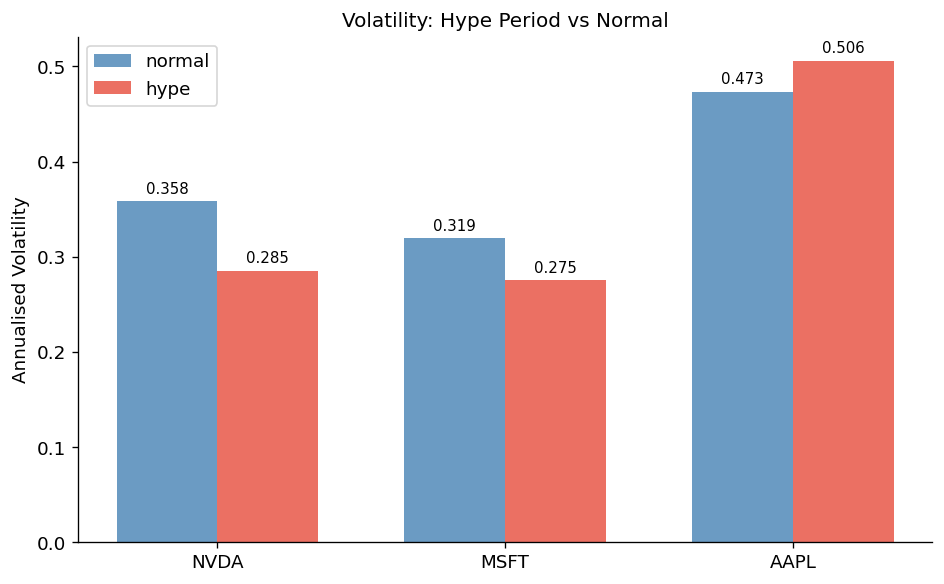

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(TICKERS))
width = 0.35

hype_v   = [df.loc[df["is_hype_period"]==1, f"{t}_volatility"].mean() for t in TICKERS]
normal_v = [df.loc[df["is_hype_period"]==0, f"{t}_volatility"].mean() for t in TICKERS]

b1 = ax.bar(x - width/2, normal_v, width, label="normal", color="steelblue", alpha=0.8)
b2 = ax.bar(x + width/2, hype_v,   width, label="hype",   color=COLORS["hype"],   alpha=0.8)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_ylabel("Annualised Volatility")
ax.set_title("Volatility: Hype Period vs Normal", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "08_volatility.png", bbox_inches="tight")
plt.show()